# Generating Figure of SDSS "K" stars SDSS spectra with SDSS photometry at the same time

This is basically straight from my code for the Science paper, but adapted for ApJ. And probably using a narrower line

This is the same message at the beginning of all jupyter notebooks in this directory. 

If you don't have the below packages, you obviously need to install them for this to work. If it doesn't work still it's extremely likely you have an outdated version of one of the packages. Alternatively, some of the histogram functions actually rely on not being the most recent version because they changed from "normed" to something else from my recollection. Or perhaps it was the other way. I am aware this was poor decision-making, but it works (if you use the right version). ¯\\_(ツ)_/¯

Also pretty much all of these commands are copied and pasted from another Jupyter notebook I made but contained tons of tries at doing this stuff (and unrelated efforts) so that's why a lot of the variables seem unnecessary to use.

Currently I'm just manually recording the f_lambda values from the Vizier portal for each object (at least I have for SDSS J2348+2116)because I'm not sure how to do this conversion with a wide filter since it really will matter given the delta lambda term is now pretty damn large.

The original units of the vizier f_lambda flux density is erg/s/cm^2/micron, so I just need to convert the per micron to per angstrom, and it should be good to be on the same units as my spectra. Actually I also need to divide by 10^-16 to get it all the way there.

In [1]:
from __future__ import print_function


import matplotlib
#matplotlib.use('pdf')


import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import gaiaxpy as xpy
import pandas as pd
import time
start = time.time()

sys.path.append('../')

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
import fix_strings as fs

print(os.getcwd())

/Users/BenKaiser/Desktop/radial_velocity_calculations/Kdwarf_impostor_plot_code


In [2]:
#target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
target_dir='/Users/BenKaiser/Desktop/Kdwarf_impostor_paper'
credentials_file= '/Users/BenKaiser/Desktop/gaia/Gaia_credentials.txt'
credentials_frame=np.genfromtxt(credentials_file,dtype=str)

#model_spec_file='J1644_fit_flambda.dms'
#target_spec_file= glob(target_dir+target_spec_file)
#model_spec_file= glob(target_dir+model_spec_file)
#print(target_spec_file)
#print(model_spec_file)

target_spec_file='SDSSJ1018p4439_sdss_spec.fits'
#sdss_spec_file='K3_-1.0_Dwarf.fits'
#gaia_file='SDSSJ1018p4439nearby_gaiaDR3.csv'
photo_file='SDSSJ1018p4439_sdssphotometry.csv'

target_spec_file='SDSSJ1213p4219_sdss_spec.fits'
#sdss_spec_file='K2_-0.5_Dwarf.fits'
#gaia_file='SDSSJ1213p4219nearby_gaiaDR3.csv'
photo_file='SDSSJ1213p4219_sdssphotometry.csv'

target_spec_file='SDSSJ1312m0229_sdss_spec.fits'
#sdss_spec_file='K1_+0.0_Dwarf.fits'
#gaia_file='SDSSJ1312m0229nearby_gaiaDR3.csv'
photo_file='SDSSJ1312m0229_sdssphotometry.csv'

In [3]:
target_spec_file='SDSSJ1451p3304_sdss_spec.fits'
#sdss_spec_file='K7_+0.0_Dwarf.fits'
#gaia_file='SDSSJ1451p3304nearby_gaiaDR3.csv'
photo_file='SDSSJ1451p3304_sdssphotometry.csv'

target_spec_file='ravg_fwctb.J1312m0229bright_400m1_quick.fits'
#sdss_spec_file='K7_+0.0_Dwarf.fits'
gaia_file='SDSSJ1312m0229nearby_gaiaDR3.csv'

target_spec_file='SDSSJ2348p2116_sdss_spec.fits'
#sdss_spec_file='K4_+0.0_Dwarf.fits'
photo_file='SDSSJ2348p2116_sdssphotometry.csv'

In [4]:
#figure_output_dir='/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/First_Revision/figures'
#figure_output_dir='/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/Science_versions/Third_Revision/figures'
figure_output_dir='/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures/'

In [5]:
#figure_output_dir='/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ApJ_reformat/figures'

I guess I have to just change the working directory instead of using a long file path for whatever reason...

In [6]:
os.chdir(target_dir)

In [7]:
target_spec, header, target_noise= spt.retrieve_sdss_spec(target_spec_file)
#target_spec, header, target_noise= spt.retrieve_spec(target_spec_file)


#sdss_spec, sdss_header, sdss_noise=spt.retrieve_sdss_spec(sdss_spec_file)
#gaia_table=Table.read(gaia_file)
#new_sampling=np.arange(np.nanmin(target_spec[0])/10.,np.nanmax(target_spec[0])/10.,2)#sampling to be used later for the Gaia XP spectrum
#new_sampling=np.arange(400.,700,2)
#print(np.nanmin(new_sampling),np.nanmax(new_sampling))




wavelengths.min:  3596.666
new_wavelengths.min(): 3595.6399451300704
"Key 'PropErr' does not exist."
trying "ivar"
ivar worked.


Read in the photometry file

In [8]:
photo_table=Table.read(photo_file)
photo_table.pprint()
conversion_factor=(10.**16)*(10**-4) #convert to 10^16 and per angstrom from per micron

bands=['u','g','r','i','z']
sdss_waves={
    'u':3.52e3,
    'g':4.82e3,
    'r':6.25e3,
    'i':7.63e3,
    'z':9.02e3,
}

 u_flam  u_flam_err  g_flam  g_flam_err ... i_flam_err  z_flam  z_flam_err
-------- ---------- -------- ---------- ... ---------- -------- ----------
6.32e-14   1.86e-14 2.88e-13   6.45e-15 ...   5.66e-15 9.92e-15   6.82e-15


In [9]:
def plot_photo():
    color='r'
    marker='o'
    size=8
    def get_band_flux(band):
        
        flux=photo_table[band+'_flam']*conversion_factor
        flux_err=photo_table[band+'_flam_err']*conversion_factor
        
        return flux, flux_err
    
    for band in bands:
        label=''
        if band=='u':
            label='SDSS photometry'
        else:
            pass
        flux,flux_err=get_band_flux(band)
        print(band,flux,flux_err)
        plt.errorbar(sdss_waves[band],flux,yerr=flux_err,linestyle='None',color=color,marker=marker,markersize=size,label=label)
    
    return 

In [10]:
print(target_noise.shape)

(2, 4582)


model_spec= spt.retrieve_model_spec(model_spec_file)
model_spec[1]=model_spec[1]*1e16

og_model=np.copy(model_spec)

### *New addition 2021-06-04 for other stitching as a test (really should make a stitching script separate from this notebook... but I'm lazy...)

target_spec_file='ravg_fwctb.WD2356m209_400m1.fits'
target_spec_file2='ravg_fwctb.WD2356m209_20190601_ted_tellcorr_400m2.fits'
target_spec, header, target_noise= spt.retrieve_spec(target_spec_file)
target_spec2,header2, target_noise2=spt.retrieve_spec(target_spec_file2)

main_kernel=10
target_dlambda=target_spec[0][400]-target_spec[0][399]
template_dlambda=sdss_spec[0][400]-sdss_spec[0][399]
print('target_dlambda',target_dlambda)
print('template_dlambda',template_dlambda)
print('target kernel',main_kernel)
template_kernel=main_kernel*(target_dlambda/template_dlambda)
print('template_kernel',template_kernel)

In [11]:
main_kernel=10

In [12]:
sm_target_spec=ps.convolve_spectrum(target_spec, header,kernel_type='box',pix_width=main_kernel)
#sm_target_spec=target_spec
#sm_sdss_spec=ps.convolve_spectrum(sdss_spec,header, kernel_type='box',pix_width=template_kernel)
#desig=gaia_table['designation'][0].split(' ')[-1]
#print(desig)
#print(gaia_table['has_xp_continuous'])
#cal_spec,sampling=xpy.calibrate([desig],username=str(credentials_frame[0]),password=str(credentials_frame[1]),truncation=True,sampling=new_sampling)

#conversion_factor=1e18 #multiple by which you have to multiply the flux in W/m^2/nm/s to get to erg/cm^2/Anstrom/s *10^-16 as used in my Goodman spectra
#gaia_spec=np.vstack([new_sampling*10.,cal_spec['flux'][0]*conversion_factor])




trim_spot=6660



809080342880379136
4838475100705496192

I rescale the flux in the 400M2 spectrum to match the 400M1 at this point. I suppose I could have it go the other way based on which one seems to be the better flux calibration. I don't remember why this flux calibration is so comparatively bad though.



wavelength-based norm range selected [6640, 6680]





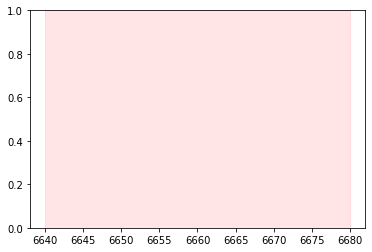

In [13]:
nsm_target_spec=ps.norm_spectrum(sm_target_spec,norm_range=[trim_spot-20,trim_spot+20])
#nsm_sdss_spec=ps.norm_spectrum(sm_sdss_spec,norm_range=[trim_spot-20,trim_spot+20])
#n_gaia_spec=ps.norm_spectrum(gaia_spec,norm_range=[trim_spot-20,trim_spot+20])






tsm_target_spec=spt.clean_spectrum(sm_target_spec,np.min(target_spec[0]), trim_spot,[])
tsm_target_spec2=spt.clean_spectrum(sm_target_spec2,trim_spot, np.max(target_spec2[0]),[])
#tsm_target_spec=spt.clean_spectrum(target_spec,np.min(target_spec[0]), trim_spot,[])
#tsm_target_spec2=spt.clean_spectrum(target_spec2,trim_spot, np.max(target_spec2[0]),[])
#tsm_target_spec=spt.clean_spectrum(nsm_target_spec,np.min(target_spec[0]), trim_spot,[])
#tsm_target_spec2=spt.clean_spectrum(nsm_target_spec2,trim_spot, np.max(target_spec2[0]),[])


#tmodel_spec=spt.clean_spectrum(og_model, np.nanmin(target_spec[0]), np.nanmax(target_spec2[0]),[])

sdss_parts=sdss_spec_file.split('_')
sdss_leg_string=sdss_parts[0]+' '+sdss_parts[2].split('.')[0]+', [Fe/H]= '+sdss_parts[1]
metal_string=sdss_parts[1].replace('+','p')
metal_string=metal_string.replace('-','m')
metal_string=metal_string.replace('.','')
filename_parts=target_spec_file.split('_')
output_filename_intro=filename_parts[0]+'_comp_'+sdss_parts[0]+sdss_parts[2].split('.')[0]+metal_string+'_'
print('metal_string',metal_string)
print('output_filename_intro',output_filename_intro)

In [14]:
filename_parts=target_spec_file.split('_')
output_filename_intro=filename_parts[0]+'_comp_SDSS_photo_'

In [15]:
target_leg_string=filename_parts[0].replace('p','+')
target_leg_string=target_leg_string.replace('m','-')

u        u_flam      
-------------------
0.06319999999999999      u_flam_err     
--------------------
0.018600000000000002
g g_flam
------
 0.288 g_flam_err
----------
   0.00645
r r_flam
------
 0.441 r_flam_err
----------
   0.00615
i i_flam
------
  0.39 i_flam_err
----------
   0.00566
z  z_flam
-------
0.00992       z_flam_err     
---------------------
0.0068200000000000005
/Users/BenKaiser/Desktop/Goodman_ref_files/line_lists/J0212_comp_lines.csv
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures
1719526582.7584572


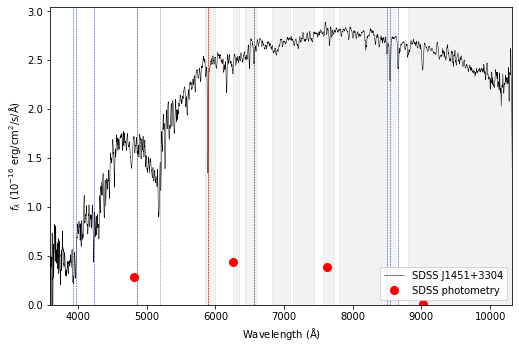

In [16]:
#plt.rc('font',size=10)
#fig= plt.figure(figsize=(15,10)) #from v1 description image size
#spt.initiate_science_plot()
#fig=plt.figure(figsize=(7.25,7.25*2./3),constrained_layout=True)
spt.start_ApJ_fig(width_cols=2,constrained_layout=True, width_height=[7.25,7.25*2./3])
label_pos=1.27
label_pos2= 0.15
label_off=110


#plt.plot(sm_target_spec[0],sm_target_spec[1], label=fs.fix_display_string(target_leg_string), color='k')
#plt.plot(nsm_sdss_spec[0],nsm_sdss_spec[1], color='r', label=fs.fix_display_string(sdss_leg_string),alpha=0.6)
#plt.plot(sampling*10.,cal_spec['flux'][0]*conversion_factor,label=fs.fix_display_string(target_leg_string+' nearby star Gaia XP'),color='r')

#plt.plot(nsm_target_spec[0],nsm_target_spec[1], label=fs.fix_display_string(target_leg_string), color='k')
#plt.plot(n_gaia_spec[0],n_gaia_spec[1], label=fs.fix_display_string(target_leg_string+' nearby star Gaia XP'),color='r')

plt.plot(sm_target_spec[0],sm_target_spec[1], label=fs.fix_display_string(target_leg_string), color='k')
#plt.plot(gaia_spec[0],gaia_spec[1], label=fs.fix_display_string(target_leg_string+' nearby star Gaia XP'),color='r')
plot_photo()



#plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model', color='r',alpha=0.7)


#plt.xlim(np.nanmin(target_spec[0]), 8500)
#plt.ylim(-0.05, 1.4)

#k_spot=np.mean([7664.899016,7698.96445153])


#plt.annotate('Na I D',xy=(5895.9241497669427, 1.0),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Li I',xy=(6707.9080032878719, 0.21),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca II\nH & K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-120, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.16),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
#plt.annotate('MgH band',xy=(5190, 0.16),xytext=(5190-210, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
#plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-60, label_pos), arrowprops=dict(arrowstyle='-['))





#plt.xlim(3740,6900)
plt.xlim(target_spec[0][0],target_spec[0][-1])
#plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
#plt.ylabel(r'$f_{\lambda}$ ($10^{-16}$ erg/cm$^{2}$/s/$\AA$)')
#plt.ylabel(r'Flux ($10^{-16}$ erg/cm$^{2}$/s/$\mathrm{\AA}$)')
plt.ylabel(r'$f_{\lambda}$ ($10^{-16}$ erg/cm$^{2}$/s/$\mathrm{\AA}$)')


#plt.ylabel(r'$f_{\lambda}$ (Arbitrary Units)') #inverse power units instead of divisions


#plt.ylabel(r'$f_{\lambda} (10^{-16}$ erg cm$^{-2}$ s $^{-1}$ $\AA^{-1})$') #inverse power units instead of divisions
#plt.ylabel(r'Flux (10$^{-16}$ erg cm$^{-2}$ s$^{-1}$ $\mathrm{\AA}^{-1}$)') #inverse power units instead of divisions

#plt.ylim(0,1.5)
#plt.ylim(0,2.0)
plt.ylim(0,)



#plt.xlabel(r'$\lambda(\AA)$')
#plt.xlabel(r'Wavelength $(\AA)$')
plt.xlabel(r'Wavelength $(\mathrm{\AA})$')



#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='J0212',show_legend=False,actually_show=False,show_label=False)


print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]

plt.legend(loc='lower right')
#plt.savefig('SDSSJ1312m0229_speccomp_'+time_string+'.pdf')#plt.grid(True)
plt.savefig(output_filename_intro+time_string+'.pdf')#plt.grid(True)


plt.show()

os.chdir(target_dir)
trim_spot=6800
hdu1= fits.open(target_spec_file)
hdu2=fits.open(target_spec_file2)
waves1=hdu1[0].data
waves2=hdu2[0].data

#output_fits='stitched_J1644_spectrum.fits'
output_fits='stitched_J2356_spectrum.fits'

list_for_hdu=[]
for index in range(0,5):
    array1=np.copy(hdu1[index].data)
    array2=np.copy(hdu2[index].data)
    spec1=np.vstack([waves1,array1])
    spec2=np.vstack([waves2,array2])
    print(spec1.shape)
    tsm_spec1=spt.clean_spectrum(spec1,np.min(spec1[0]), trim_spot,[])
    tsm_spec2=spt.clean_spectrum(spec2,trim_spot, np.max(spec2[0]),[])
    stitched_spec=np.hstack([tsm_spec1,tsm_spec2])
    print(stitched_spec.shape)
    if index==0:
        out_hdu=fits.PrimaryHDU(stitched_spec[1], header=header)
        list_for_hdu.append(out_hdu)
    else:
        new_hdu=fits.ImageHDU(stitched_spec[1])
        list_for_hdu.append(new_hdu)
        
print(list_for_hdu)
hdulist=fits.HDUList(list_for_hdu)
os.chdir(figure_output_dir)
hdulist.writeto(output_fits)